In [1]:
datafolder = r"/home/yslcoat/data/coco/"
annotations_folder = r"annotations"
test_folder = r"test2017"
train_folder = r"train2017"
val_folder = r"val2017"

In [2]:
import json 
import os 
import pathlib

In [3]:
validation_annotation = json.load(open(os.path.join(datafolder, annotations_folder, "instances_val2017.json")))

In [4]:
validation_annotation.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [5]:
validation_annotation['annotations'][0]

{'segmentation': [[510.66,
   423.01,
   511.72,
   420.03,
   510.45,
   416.0,
   510.34,
   413.02,
   510.77,
   410.26,
   510.77,
   407.5,
   510.34,
   405.16,
   511.51,
   402.83,
   511.41,
   400.49,
   510.24,
   398.16,
   509.39,
   397.31,
   504.61,
   399.22,
   502.17,
   399.64,
   500.89,
   401.66,
   500.47,
   402.08,
   499.09,
   401.87,
   495.79,
   401.98,
   490.59,
   401.77,
   488.79,
   401.77,
   485.39,
   398.58,
   483.9,
   397.31,
   481.56,
   396.35,
   478.48,
   395.93,
   476.68,
   396.03,
   475.4,
   396.77,
   473.92,
   398.79,
   473.28,
   399.96,
   473.49,
   401.87,
   474.56,
   403.47,
   473.07,
   405.59,
   473.39,
   407.71,
   476.68,
   409.41,
   479.23,
   409.73,
   481.56,
   410.69,
   480.4,
   411.85,
   481.35,
   414.93,
   479.86,
   418.65,
   477.32,
   420.03,
   476.04,
   422.58,
   479.02,
   422.58,
   480.29,
   423.01,
   483.79,
   419.93,
   486.66,
   416.21,
   490.06,
   415.57,
   492.18,
   416.85,

In [6]:
train_annotation = json.load(open(os.path.join(datafolder, annotations_folder, "instances_train2017.json")))

In [7]:
train_annotation['categories']

[{'supercategory': 'person', 'id': 1, 'name': 'person'},
 {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'},
 {'supercategory': 'vehicle', 'id': 3, 'name': 'car'},
 {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'},
 {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'},
 {'supercategory': 'vehicle', 'id': 6, 'name': 'bus'},
 {'supercategory': 'vehicle', 'id': 7, 'name': 'train'},
 {'supercategory': 'vehicle', 'id': 8, 'name': 'truck'},
 {'supercategory': 'vehicle', 'id': 9, 'name': 'boat'},
 {'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'},
 {'supercategory': 'outdoor', 'id': 11, 'name': 'fire hydrant'},
 {'supercategory': 'outdoor', 'id': 13, 'name': 'stop sign'},
 {'supercategory': 'outdoor', 'id': 14, 'name': 'parking meter'},
 {'supercategory': 'outdoor', 'id': 15, 'name': 'bench'},
 {'supercategory': 'animal', 'id': 16, 'name': 'bird'},
 {'supercategory': 'animal', 'id': 17, 'name': 'cat'},
 {'supercategory': 'animal', 'id': 18, 'name': 'dog'},

In [8]:
image_paths = [pathlib.Path(datafolder, train_folder, f"{img['file_name']}") for img in train_annotation["images"]] # Or alternatively list all image files in the directory, idk whats best

In [9]:
image_paths[0]

PosixPath('/home/yslcoat/data/coco/train2017/000000391895.jpg')

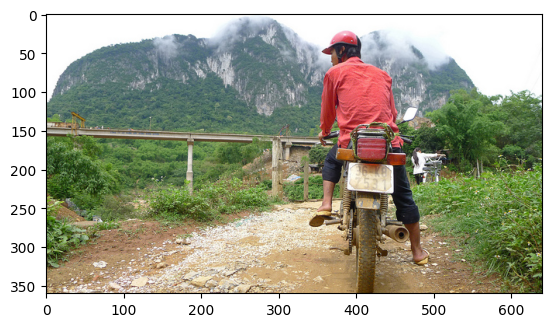

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(image_paths[0])
imgplot = plt.imshow(img)
plt.show()

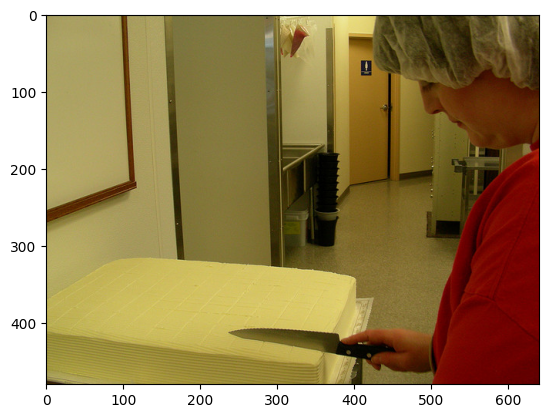

In [11]:
img = mpimg.imread(image_paths[1])
imgplot = plt.imshow(img)
plt.show()

In [12]:
image_paths[0]

PosixPath('/home/yslcoat/data/coco/train2017/000000391895.jpg')

In [13]:
str(image_paths[0])

'/home/yslcoat/data/coco/train2017/000000391895.jpg'

In [14]:
def get_item(idx):
    annotation = train_annotation["annotations"][idx]
    image_paths = [pathlib.Path(datafolder, train_folder, f"{img['file_name']}") for img in train_annotation["images"]]
    img_id = annotation["image_id"]
    image_path = next((s for s in image_paths if str(img_id) in str(s)), None)
    return image_path, annotation

In [15]:
image, annotation = get_item(0)
image, annotation

(PosixPath('/home/yslcoat/data/coco/train2017/000000558840.jpg'),
 {'segmentation': [[239.97,
    260.24,
    222.04,
    270.49,
    199.84,
    253.41,
    213.5,
    227.79,
    259.62,
    200.46,
    274.13,
    202.17,
    277.55,
    210.71,
    249.37,
    253.41,
    237.41,
    264.51,
    242.54,
    261.95,
    228.87,
    271.34]],
  'area': 2765.1486500000005,
  'iscrowd': 0,
  'image_id': 558840,
  'bbox': [199.84, 200.46, 77.71, 70.88],
  'category_id': 58,
  'id': 156})

In [16]:
import os
import pathlib
from PIL import Image
from typing import Dict, List
import json
from collections import defaultdict

import torch
from torch.utils.data import Dataset
from torchvision.ops import box_convert


class CocoDataset(Dataset):
    def __init__(
        self,
        root_dir: pathlib.Path,
        partition: str = "train",
        convert_bbox_format: bool = True,
        transforms=None,
    ) -> None:
        self.root_dir = pathlib.Path(root_dir)
        self.convert_bbox_format = convert_bbox_format
        self.partition = partition
        self.transforms = transforms
        self.annotations_file = self.root_dir / "annotations" / f"instances_{partition}2017.json"
        self.images_dir = self.root_dir / f"{partition}2017"

        try:
            with open(self.annotations_file) as f:
                self.coco_data = json.load(f)
        except Exception as e:
            raise ValueError(f"Error loading annotations: {e}")

        self.image_info = {img["id"]: img for img in self.coco_data.get("images", [])}
        self.image_ids = list(self.image_info.keys())

        self.img_to_anns = defaultdict(list)
        for ann in self.coco_data.get("annotations", []):
            self.img_to_anns[ann["image_id"]].append(ann)

    def __len__(self) -> int:
        return len(self.image_ids)

    def load_image(self, image_path: pathlib.Path) -> Image.Image:
        with Image.open(image_path) as image:
            return image.convert("RGB")

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        img_id = self.image_ids[idx]
        image_meta = self.image_info[img_id]
        image_path = self.images_dir / image_meta["file_name"]
        image = self.load_image(image_path)

        anns: List[dict] = self.img_to_anns.get(img_id, [])
        if len(anns) > 0:
            boxes = torch.tensor([ann["bbox"] for ann in anns], dtype=torch.float32)
            if self.convert_bbox_format:
                boxes = box_convert(boxes, in_fmt="xywh", out_fmt="xyxy")
            labels = torch.tensor([ann.get("category_id", 0) for ann in anns], dtype=torch.int64)
            area = torch.tensor([ann.get("area", 0.0) for ann in anns], dtype=torch.float32)
            iscrowd = torch.tensor([ann.get("iscrowd", 0) for ann in anns], dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": area,
            "iscrowd": iscrowd,
            "image_id": torch.tensor([img_id], dtype=torch.int64),
            "orig_size": torch.tensor([image_meta["height"], image_meta["width"]], dtype=torch.int64),
            "size": torch.tensor([image_meta["height"], image_meta["width"]], dtype=torch.int64),
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        return {"image": image, "target": target}


In [17]:
"""Augmentation utilities for COCO-style detection/segmentation samples.

All transforms follow the contract used in torchvision detection datasets:
`transform(image, target) -> (image, target)` where:
- `image` is a PIL image during geometric preprocessing, then a tensor at output.
- `target` is a dict with keys like `boxes`, `labels`, and optionally `masks`.

Key rules implemented here:
- Keep aspect ratio with deterministic letterbox padding.
- Apply the exact same geometric transform to image and labels.
- Use separate interpolation: bilinear for image, nearest for masks/segmentation.
"""

from __future__ import annotations

import random
from dataclasses import dataclass
from typing import Callable, List, Sequence, Tuple

from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF


def _as_hw(size: int | Tuple[int, int]) -> Tuple[int, int]:
    if isinstance(size, int):
        return (size, size)
    if len(size) != 2:
        raise ValueError(f"size must be int or (h, w), got {size!r}")
    h, w = size
    return int(h), int(w)


def _clip_boxes_to_bounds(boxes: torch.Tensor, width: int, height: int) -> torch.Tensor:
    if boxes.numel() == 0:
        return boxes
    boxes = boxes.clone()
    boxes[:, 0] = boxes[:, 0].clamp(0.0, float(width))
    boxes[:, 2] = boxes[:, 2].clamp(0.0, float(width))
    boxes[:, 1] = boxes[:, 1].clamp(0.0, float(height))
    boxes[:, 3] = boxes[:, 3].clamp(0.0, float(height))
    return boxes


def _filter_degenerate_boxes(target: dict) -> dict:
    boxes = target["boxes"]
    if boxes.numel() == 0:
        if "area" in target:
            target["area"] = torch.zeros((0,), dtype=torch.float32, device=boxes.device)
        return target

    widths = (boxes[:, 2] - boxes[:, 0]).clamp(min=0.0)
    heights = (boxes[:, 3] - boxes[:, 1]).clamp(min=0.0)
    keep = (widths > 1e-6) & (heights > 1e-6)

    target["boxes"] = boxes[keep]
    target["labels"] = target["labels"][keep]
    target["iscrowd"] = target["iscrowd"][keep]
    if "area" in target:
        filtered_boxes = target["boxes"]
        target["area"] = (
            (filtered_boxes[:, 2] - filtered_boxes[:, 0]).clamp(min=0.0)
            * (filtered_boxes[:, 3] - filtered_boxes[:, 1]).clamp(min=0.0)
        )

    if "masks" in target and isinstance(target["masks"], torch.Tensor):
        target["masks"] = target["masks"][keep]

    return target


class _Compose:
    def __init__(self, transforms: Sequence[Callable]):
        self.transforms = list(transforms)

    def __call__(self, image: Image.Image, target: dict):
        for transform in self.transforms:
            image, target = transform(image, target)
        return image, target


class Letterbox:
    """Resize while preserving aspect ratio, then pad to fixed output size."""

    def __init__(
        self,
        output_size: int | Tuple[int, int],
        fill: int | Tuple[int, int, int] = (114, 114, 114),
        image_interpolation: TF.InterpolationMode = TF.InterpolationMode.BILINEAR,
        antialias: bool = True,
    ) -> None:
        self.output_size = output_size
        self.fill = fill
        self.image_interpolation = image_interpolation
        self.antialias = antialias

    def __call__(self, image: Image.Image, target: dict):
        target = dict(target)
        out_h, out_w = _as_hw(self.output_size)
        in_w, in_h = image.size

        scale = min(out_w / in_w, out_h / in_h)
        new_w = max(1, int(round(in_w * scale)))
        new_h = max(1, int(round(in_h * scale)))

        pad_w = out_w - new_w
        pad_h = out_h - new_h
        left = pad_w // 2
        top = pad_h // 2
        right = pad_w - left
        bottom = pad_h - top

        image = TF.resize(image, size=[new_h, new_w], interpolation=self.image_interpolation, antialias=self.antialias)
        image = TF.pad(image, padding=[left, top, right, bottom], fill=self.fill, padding_mode="constant")

        boxes = target["boxes"]
        if boxes.numel() > 0:
            boxes = boxes * scale
            boxes[:, 0::2] += torch.tensor([left, left], dtype=boxes.dtype, device=boxes.device)
            boxes[:, 1::2] += torch.tensor([top, top], dtype=boxes.dtype, device=boxes.device)
            boxes = _clip_boxes_to_bounds(boxes, out_w, out_h)
            target["boxes"] = boxes

        masks = target.get("masks")
        if isinstance(masks, torch.Tensor) and masks.numel() > 0:
            # Nearest-neighbor for class masks / segmentation logits
            masks = F.interpolate(
                masks.unsqueeze(1).float(),
                size=(new_h, new_w),
                mode="nearest",
            )
            masks = masks.squeeze(1)
            masks = F.pad(masks, (left, right, top, bottom), mode="constant", value=0)
            target["masks"] = masks.to(torch.long)

        target["size"] = torch.tensor([out_h, out_w], dtype=torch.int64)
        target["orig_size"] = torch.tensor([in_h, in_w], dtype=torch.int64)
        target["scale"] = torch.tensor([scale], dtype=torch.float32)
        target["pad"] = torch.tensor([top, left], dtype=torch.int64)

        return image, _filter_degenerate_boxes(target)


class RandomHorizontalFlip:
    def __init__(self, p: float = 0.5):
        self.p = p

    def __call__(self, image: Image.Image, target: dict):
        if random.random() > self.p:
            return image, target

        w = image.width
        image = TF.hflip(image)

        target = dict(target)
        boxes = target["boxes"]
        if boxes.numel() > 0:
            x1 = boxes[:, 0].clone()
            x2 = boxes[:, 2].clone()
            boxes[:, 0] = w - x2
            boxes[:, 2] = w - x1
            target["boxes"] = boxes

        masks = target.get("masks")
        if isinstance(masks, torch.Tensor) and masks.numel() > 0:
            target["masks"] = torch.flip(masks, dims=[2])

        return image, target


class RandomPhotometric:
    """Safe color jitter for image-only augmentation."""

    def __init__(
        self,
        brightness: float = 0.2,
        contrast: float = 0.2,
        saturation: float = 0.2,
        hue: float = 0.1,
        p: float = 0.5,
    ) -> None:
        self.p = p
        self.jitter = T.ColorJitter(brightness=brightness, contrast=contrast, saturation=saturation, hue=hue)

    def __call__(self, image: Image.Image, target: dict):
        if random.random() < self.p:
            image = self.jitter(image)
        return image, target


class MultiScaleLetterbox:
    """Pick a random square output side and apply letterbox per batch/sample."""

    def __init__(
        self,
        min_size: int = 320,
        max_size: int = 640,
        stride: int = 32,
        fill: int | Tuple[int, int, int] = (114, 114, 114),
    ) -> None:
        if min_size > max_size:
            raise ValueError("min_size must be <= max_size")
        if stride <= 0:
            raise ValueError("stride must be > 0")
        self.min_size = min_size
        self.max_size = max_size
        self.stride = stride
        self.fill = fill

    def __call__(self, image: Image.Image, target: dict):
        min_v = self.min_size
        max_v = self.max_size
        stride = self.stride
        choices = list(range(min_v, max_v + 1, stride))
        if not choices:
            choices = [min_v]
        size = random.choice(choices)
        return Letterbox((size, size), fill=self.fill)(image, target)


class ToTensorNormalize:
    """Convert image to CHW float tensor and normalize for training."""

    def __init__(self, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        self.normalize = T.Normalize(mean=mean, std=std)

    def __call__(self, image: Image.Image, target: dict):
        image_t = TF.to_tensor(image)
        image_t = self.normalize(image_t)
        return image_t, target


@dataclass
class CocoTransformConfig:
    multiscale: bool = False
    fixed_size: int = 640
    min_size: int = 320
    max_size: int = 640
    stride: int = 32
    enable_flip: bool = True
    enable_color_jitter: bool = True
    fill: int | Tuple[int, int, int] = (114, 114, 114)


def build_train_transform(config: CocoTransformConfig):
    transforms: List[Callable] = []

    if config.enable_color_jitter:
        transforms.append(RandomPhotometric(p=0.6))

    if config.multiscale:
        transforms.append(MultiScaleLetterbox(config.min_size, config.max_size, config.stride, fill=config.fill))
    else:
        transforms.append(Letterbox(config.fixed_size, fill=config.fill))

    if config.enable_flip:
        transforms.append(RandomHorizontalFlip(p=0.5))

    transforms.append(ToTensorNormalize())
    return _Compose(transforms)


In [18]:
transforms = build_train_transform(CocoTransformConfig(multiscale=True, enable_color_jitter=True))
dataset = CocoDataset(pathlib.Path(datafolder), "train", transforms=transforms)


In [19]:
dataset[0]

{'image': tensor([[[-0.1657, -0.1657, -0.1657,  ..., -0.1657, -0.1657, -0.1657],
          [-0.1657, -0.1657, -0.1657,  ..., -0.1657, -0.1657, -0.1657],
          [-0.1657, -0.1657, -0.1657,  ..., -0.1657, -0.1657, -0.1657],
          ...,
          [-0.1657, -0.1657, -0.1657,  ..., -0.1657, -0.1657, -0.1657],
          [-0.1657, -0.1657, -0.1657,  ..., -0.1657, -0.1657, -0.1657],
          [-0.1657, -0.1657, -0.1657,  ..., -0.1657, -0.1657, -0.1657]],
 
         [[-0.0399, -0.0399, -0.0399,  ..., -0.0399, -0.0399, -0.0399],
          [-0.0399, -0.0399, -0.0399,  ..., -0.0399, -0.0399, -0.0399],
          [-0.0399, -0.0399, -0.0399,  ..., -0.0399, -0.0399, -0.0399],
          ...,
          [-0.0399, -0.0399, -0.0399,  ..., -0.0399, -0.0399, -0.0399],
          [-0.0399, -0.0399, -0.0399,  ..., -0.0399, -0.0399, -0.0399],
          [-0.0399, -0.0399, -0.0399,  ..., -0.0399, -0.0399, -0.0399]],
 
         [[ 0.1825,  0.1825,  0.1825,  ...,  0.1825,  0.1825,  0.1825],
          [ 0.1825,